In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("RTA Dataset.csv")
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


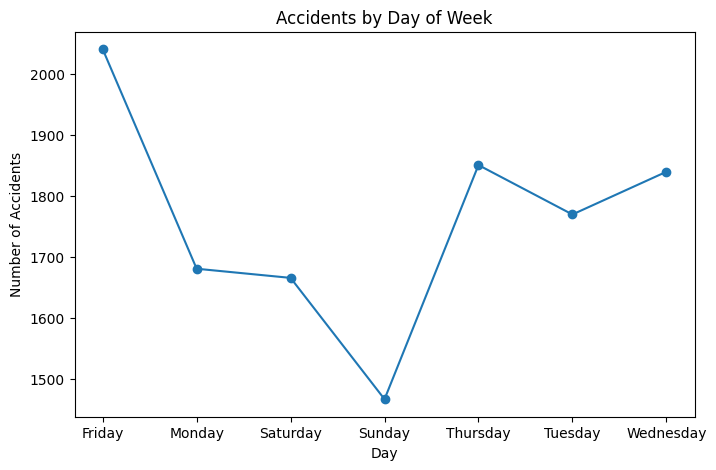

In [2]:
day_counts = data['Day_of_week'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(day_counts.index, day_counts.values, marker='o')
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.show()

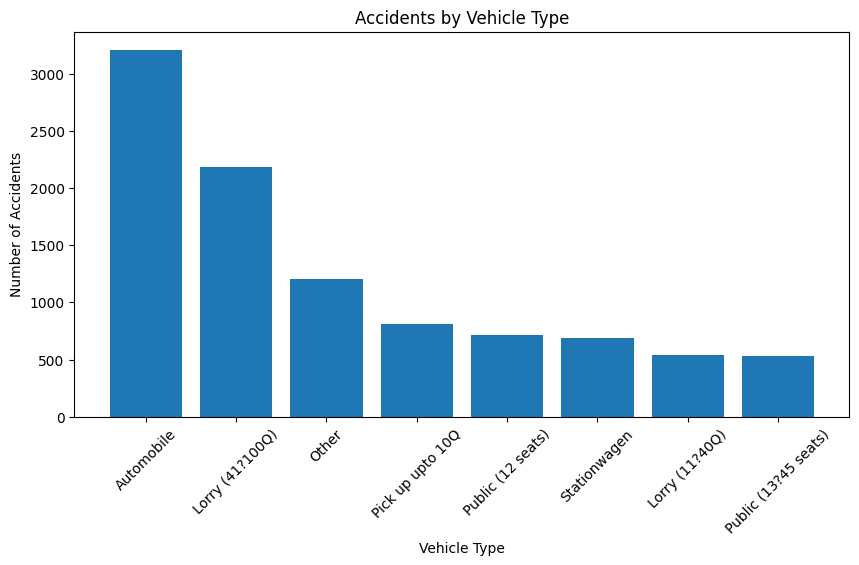

In [3]:
vehicle_counts = data['Type_of_vehicle'].value_counts().head(8)

plt.figure(figsize=(10,5))
plt.bar(vehicle_counts.index, vehicle_counts.values)

plt.title("Accidents by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

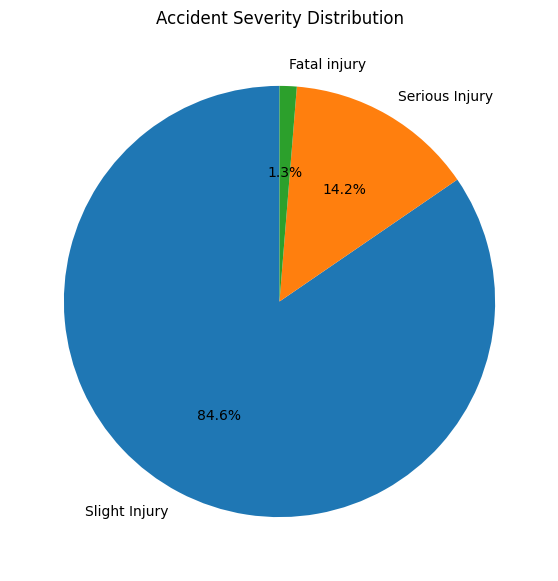

In [4]:
severity_counts = data['Accident_severity'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(severity_counts,
        labels=severity_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Accident Severity Distribution")
plt.show()

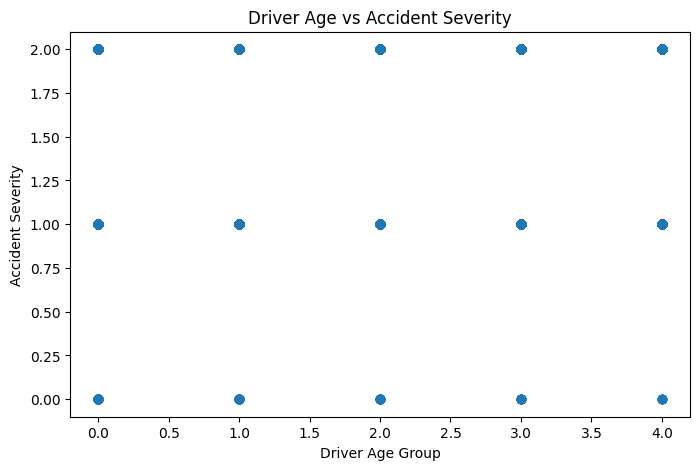

In [5]:
age_codes = data['Age_band_of_driver'].astype('category').cat.codes
severity_codes = data['Accident_severity'].astype('category').cat.codes

plt.figure(figsize=(8,5))
plt.scatter(age_codes, severity_codes)

plt.title("Driver Age vs Accident Severity")
plt.xlabel("Driver Age Group")
plt.ylabel("Accident Severity")

plt.show()

/tmp/ipykernel_563/3952646596.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_values = pd.to_datetime(data['Time'], errors='coerce').dt.hour


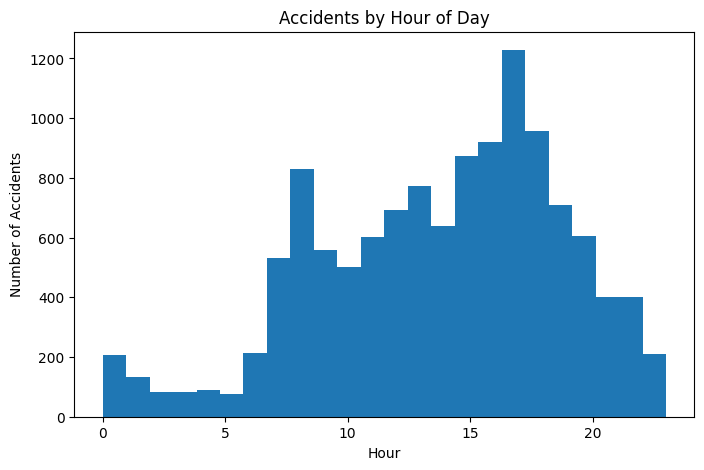

In [6]:
time_values = pd.to_datetime(data['Time'], errors='coerce').dt.hour

plt.figure(figsize=(8,5))
plt.hist(time_values, bins=24)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()

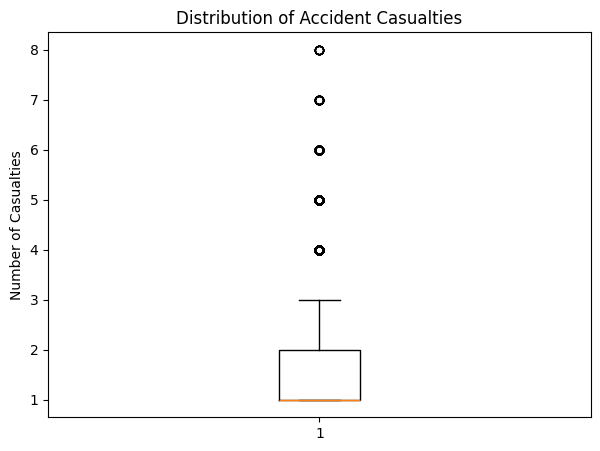

In [7]:
casualties = data['Number_of_casualties'].dropna()

plt.figure(figsize=(7,5))
plt.boxplot(casualties)

plt.title("Distribution of Accident Casualties")
plt.ylabel("Number of Casualties")

plt.show()

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("RTA Dataset.csv")

data = data[['Age_band_of_driver','Driving_experience','Type_of_vehicle']]

data = data.dropna()

encoder = LabelEncoder()

for col in data.columns:
    data[col] = encoder.fit_transform(data[col])

# KMeans clustering
model = KMeans(n_clusters=3)

data['Cluster'] = model.fit_predict(data)

print(data.head())

   Age_band_of_driver  Driving_experience  Type_of_vehicle  Cluster
0                   0                   0                0        1
1                   1                   3               11        2
2                   0                   0                5        0
3                   0                   2               11        2
6                   0                   1                0        1


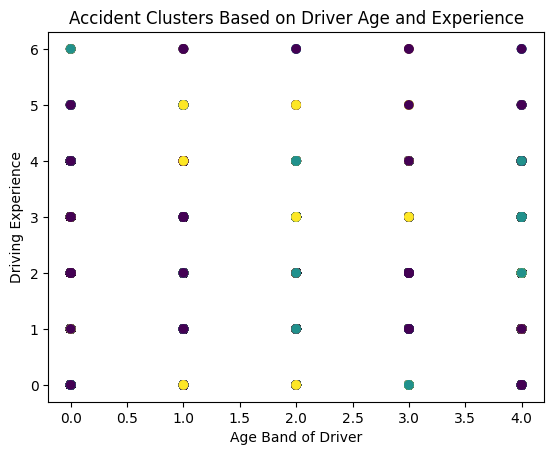

In [7]:
import matplotlib.pyplot as plt

plt.scatter(data['Age_band_of_driver'], data['Driving_experience'], c=data['Cluster'])

plt.xlabel("Age Band of Driver")
plt.ylabel("Driving Experience")
plt.title("Accident Clusters Based on Driver Age and Experience")

plt.show()

In [2]:
import matplotlib.pyplot as plt

plt.scatter(data['Age_band_of_driver'], data['Driving_experience'], c=data['Cluster'])

plt.xlabel("Age Band of Driver")
plt.ylabel("Driving Experience")
plt.title("Accident Clusters Based on Driver Age and Experience")

plt.show()

NameError: name 'data' is not defined